In [1]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [2]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [3]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

100%|██████████| 170M/170M [00:03<00:00, 48.1MB/s]


In [4]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [5]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [6]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

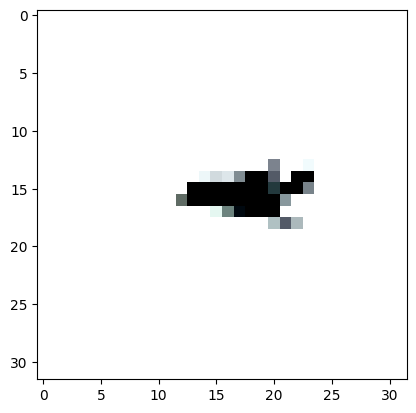

In [7]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [8]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [9]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [10]:
config = {
    'num_epochs': 10,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [11]:
class Trainer:
    def __init__(self, config, model_name="BasicCNN", transform=None):
        self.config = config
        self.transform = transform

        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

        if model_name == "BasicCNN":
            self.model = BasicCNN().to(self.device)
        elif model_name == "ResNet18":
            self.model = ResNet18().to(self.device)
        else:
            raise ValueError(f"Unknown model: {model_name}")

        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()

        self.epoch_train_accs = []
        self.epoch_val_accs = []
        self.final_test_acc = []
        self.epoch_train_losses = []
        self.epoch_val_losses = []

        self.setup_dataloaders()

    def setup_dataloaders(self):
        train_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_ds = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        tr_idx, val_idx = train_test_split(
            list(range(len(train_full))),
            test_size=self.config['test_size'],
            random_state=42,
            shuffle=True
        )
        tr_ds = Subset(train_full, tr_idx)
        val_ds = Subset(train_full, val_idx)

        self.train_loader = DataLoader(dataset=tr_ds, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_ds, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_ds, batch_size=self.config['batch_size'], shuffle=False)

    def run(self):
        for epoch in range(self.config['num_epochs']):
            tr_loss, tr_acc = self.train_step()
            val_loss, val_acc = self.val_step()

            print(f"Epoch {epoch + 1}/{self.config['num_epochs']} | train_loss={tr_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.2f}%")
            self.epoch_train_accs.append(tr_acc)
            self.epoch_val_accs.append(val_acc)
            self.epoch_train_losses.append(tr_loss)
            self.epoch_val_losses.append(val_loss)

        test_loss, test_acc = self.test_step()
        print(f'Test loss: {test_loss:.4f}, test acc: {test_acc:.2f}%')
        self.final_test_acc.append(test_acc)

        self.plot_accuracies()
        self.plot_losses()

    def train_step(self):
        self.model.train()

        running_loss = 0.0
        num_correct = 0
        n_samples = 0

        for imgs, lbls in tqdm(self.train_loader):
            imgs, lbls = imgs.to(self.device), lbls.to(self.device)

            self.optimizer.zero_grad()

            logits = self.model(imgs)
            loss = self.loss_function(logits, lbls)
            loss.backward()
            self.optimizer.step()

            running_loss += loss.item()
            predicted = torch.argmax(logits, dim=1)
            num_correct += (predicted == lbls).sum().item()
            n_samples += lbls.size(0)

        self.scheduler.step()

        avg_loss = running_loss / len(self.train_loader)
        accuracy = num_correct / n_samples * 100
        return avg_loss, accuracy

    def val_step(self):
        self.model.eval()

        running_loss = 0.0
        num_correct = 0
        n_samples = 0

        for imgs, lbls in tqdm(self.val_loader):
            imgs, lbls = imgs.to(self.device), lbls.to(self.device)

            with torch.no_grad():
                logits = self.model(imgs)
            loss = self.loss_function(logits, lbls)

            running_loss += loss.item()
            predicted = torch.argmax(logits, dim=1)
            num_correct += (predicted == lbls).sum().item()
            n_samples += lbls.size(0)

        avg_loss = running_loss / len(self.val_loader)
        accuracy = num_correct / n_samples * 100
        return avg_loss, accuracy

    def test_step(self):
        self.model.eval()

        running_loss = 0.0
        num_correct = 0
        n_samples = 0

        for imgs, lbls in tqdm(self.test_loader):
            imgs, lbls = imgs.to(self.device), lbls.to(self.device)

            with torch.no_grad():
                logits = self.model(imgs)
            loss = self.loss_function(logits, lbls)

            running_loss += loss.item()
            predicted = torch.argmax(logits, dim=1)
            num_correct += (predicted == lbls).sum().item()
            n_samples += lbls.size(0)

        avg_loss = running_loss / len(self.test_loader)
        accuracy = num_correct / n_samples * 100
        return avg_loss, accuracy

    def plot_accuracies(self):
        epochs = range(1, self.config['num_epochs'] + 1)
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, self.epoch_train_accs, label='Train Accuracy')
        plt.plot(epochs, self.epoch_val_accs, label='Validation Accuracy')
        if self.final_test_acc:
            plt.axhline(y=self.final_test_acc[0], color='r', linestyle='--', label='Test Accuracy')
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy (%)')
        plt.title('Accuracy over Epochs')
        plt.legend()
        plt.grid(True)
        plt.show()

    def plot_losses(self):
        epochs = range(1, self.config['num_epochs'] + 1)
        plt.figure(figsize=(10, 6))
        plt.plot(epochs, self.epoch_train_losses, label='Train Loss')
        plt.plot(epochs, self.epoch_val_losses, label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Loss over Epochs')
        plt.legend()
        plt.grid(True)
        plt.show()

In [12]:
trainer_basic = Trainer(config, model_name="BasicCNN", transform=transform)

100%|██████████| 79/79 [00:02<00:00, 31.68it/s]


Epoch 1/10 | train_loss=1.7603 val_loss=1.5688 val_acc=42.92%


100%|██████████| 79/79 [00:02<00:00, 30.78it/s]


Epoch 2/10 | train_loss=1.5264 val_loss=1.5179 val_acc=44.84%


100%|██████████| 79/79 [00:04<00:00, 17.16it/s]


...

Epoch 9/10 | train_loss=1.2252 val_loss=1.3345 val_acc=52.50%


100%|██████████| 79/79 [00:02<00:00, 30.87it/s]


Epoch 10/10 | train_loss=1.2061 val_loss=1.3104 val_acc=53.40%


100%|██████████| 79/79 [00:02<00:00, 31.48it/s]


Test loss: 1.3132, test acc: 53.22%


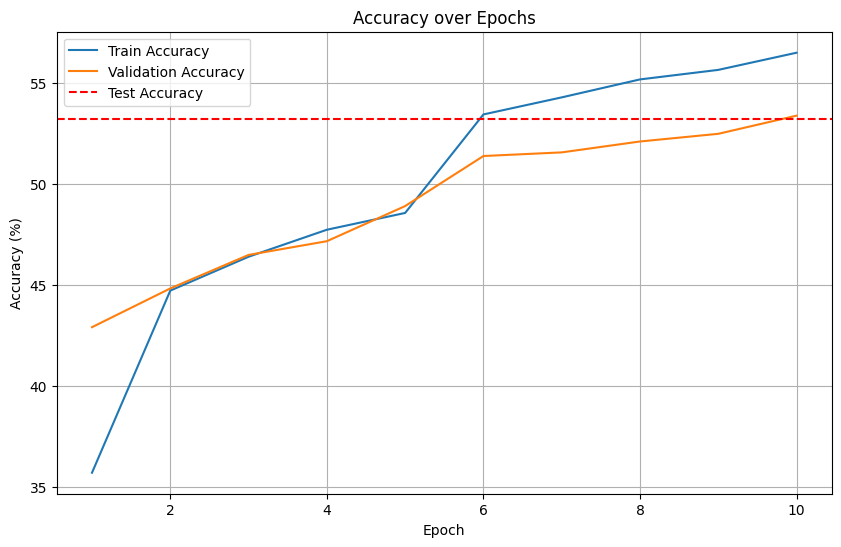

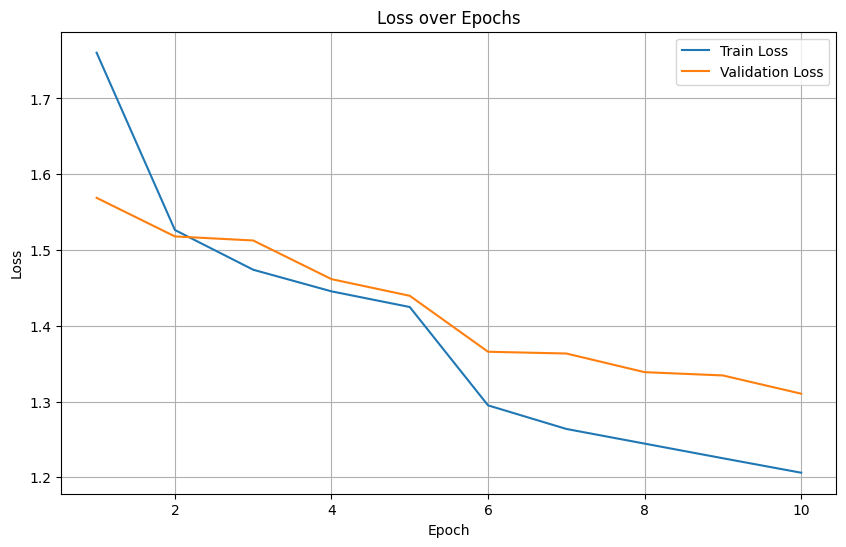

In [13]:
trainer_basic.run()

# ResNet-18

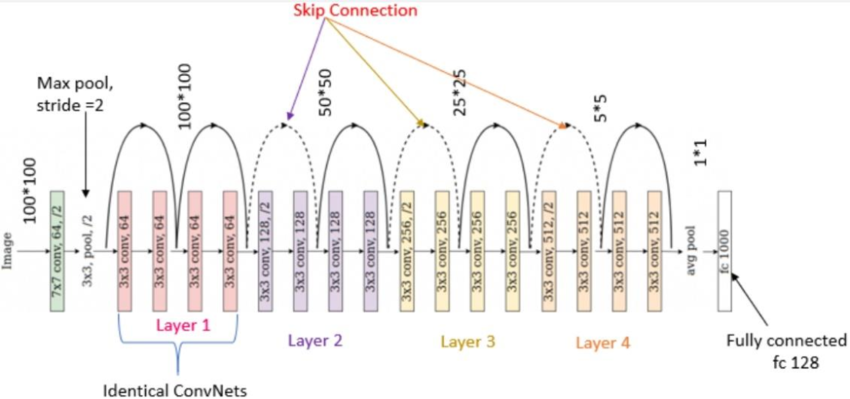

In [14]:
class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.act = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.downsample = downsample

    def forward(self, x):
        identity = x

        if self.downsample is not None:
            identity = self.downsample(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity
        out = self.act(out)

        return out


class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.stem_conv = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.stem_bn = nn.BatchNorm2d(64)
        self.stem_act = nn.ReLU(inplace=True)
        self.stem_pool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(64, num_blocks=2)
        self.layer2 = self._make_layer(128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(512, num_blocks=2, stride=2)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )

        blocks = [ResNetBlock(self.in_channels, out_channels, stride, downsample)]
        self.in_channels = out_channels
        for _ in range(1, num_blocks):
            blocks.append(ResNetBlock(self.in_channels, out_channels))

        return nn.Sequential(*blocks)

    def forward(self, x):
        x = self.stem_conv(x)
        x = self.stem_bn(x)
        x = self.stem_act(x)
        x = self.stem_pool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)

        return x

$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [15]:
def plot_confusion_matrix(trainer_obj):
    trainer_obj.model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for imgs, lbls in trainer_obj.test_loader:
            imgs, lbls = imgs.to(trainer_obj.device), lbls.to(trainer_obj.device)
            outputs = trainer_obj.model(imgs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(lbls.cpu().numpy())

    cm = confusion_matrix(all_targets, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.show()

In [16]:
trainer_resnet = Trainer(config, model_name="ResNet18", transform=transform)

100%|██████████| 79/79 [00:03<00:00, 20.81it/s]


Epoch 1/10 | train_loss=1.8552 val_loss=1.6865 val_acc=45.46%


100%|██████████| 79/79 [00:03<00:00, 21.47it/s]


Epoch 2/10 | train_loss=1.3714 val_loss=1.2434 val_acc=54.03%


100%|██████████| 79/79 [00:03<00:00, 25.29it/s]


...

Epoch 9/10 | train_loss=0.3067 val_loss=0.8496 val_acc=74.97%


100%|██████████| 79/79 [00:03<00:00, 23.87it/s]


Epoch 10/10 | train_loss=0.2245 val_loss=0.9698 val_acc=74.61%


100%|██████████| 79/79 [00:03<00:00, 21.32it/s]


Test loss: 0.9781, test acc: 74.41%


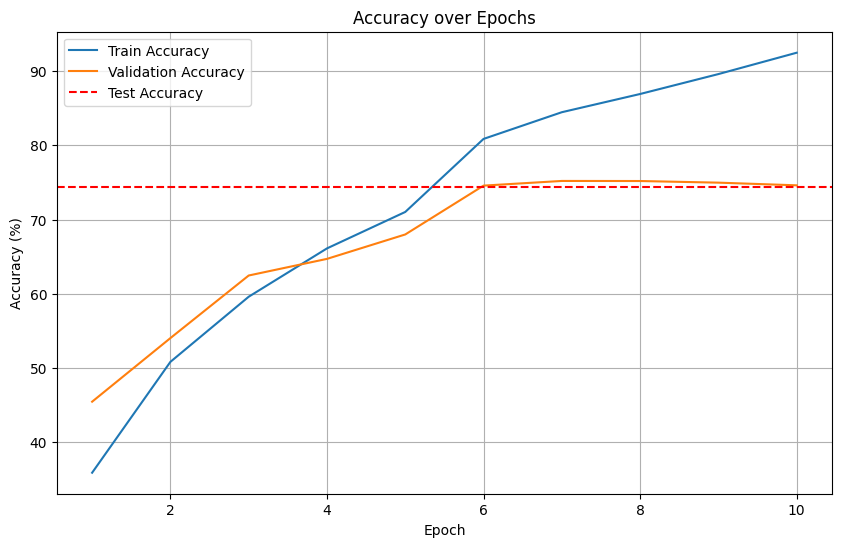

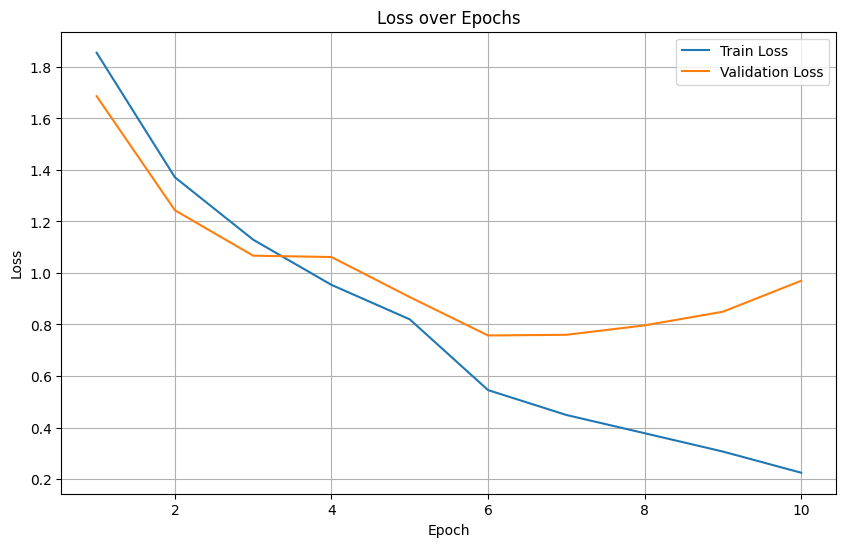

In [17]:
trainer_resnet.run()

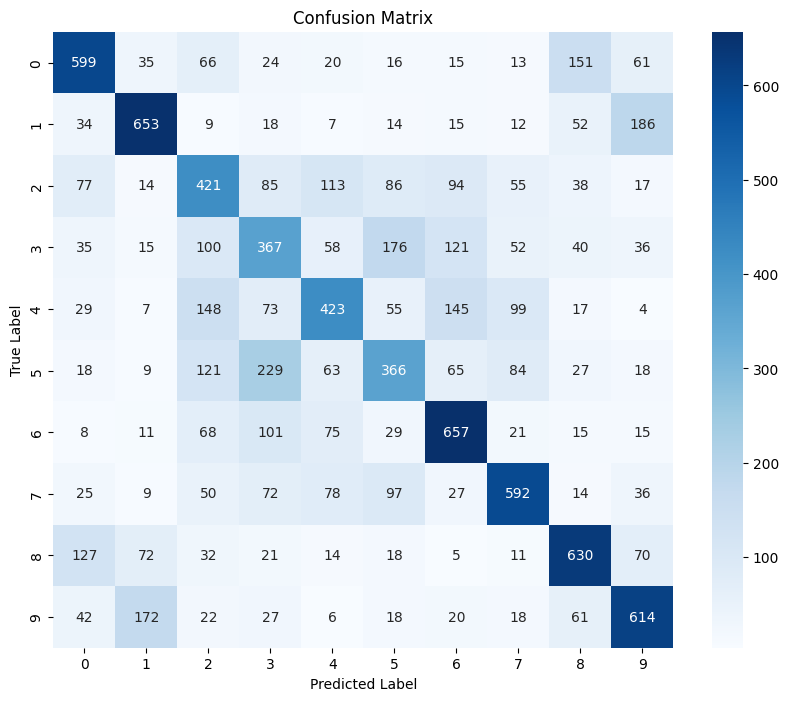

In [18]:
plot_confusion_matrix(trainer_basic)

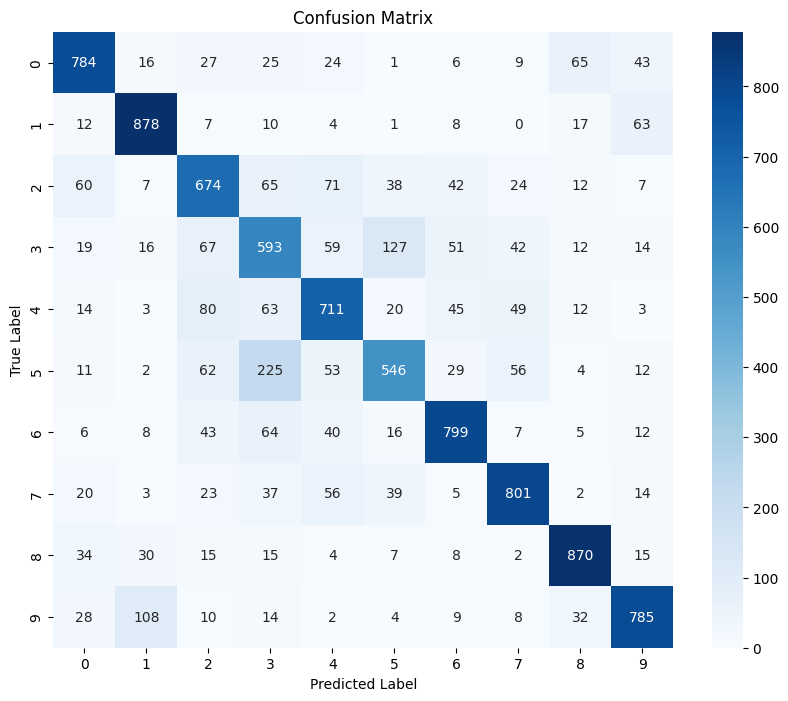

In [19]:
plot_confusion_matrix(trainer_resnet)

In [22]:
print(train_dataset.classes[3])
print(train_dataset.classes[5])

cat
dog


ResNet18 значительно улучшает качество классификации по сравнению с простой CNN. Модель всё ещё путает похожие классы (например, кошки и собаки), но общая точность заметно выше.